### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial.transform import Rotation as Rot

### Input data:

In [2]:
mp = 179.7      #  (submerged pipe weight) [kg/m]
N = 25     # number of modelling nodes

In [3]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI = (508-33*2)/1000 # Inner diameter of pipe, [m]

In [4]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [5]:
Fx_0 = 1515*1000
Fy_0 = 0.8*Fx_0
LTD = 209

In [6]:
E = 207e9
G = 79.3e9
nu_p = 0.3

In [7]:
# Vessel model from Thor I. Fossen - MSS - 'rig.m'

In [8]:
# integration parameters
tspan = (0.,70.)

### Main functions:

In [9]:
A = np.pi * ((d0/2)**2 - (dI/2)**2)

In [10]:
m = (dI/2)/ (d0/2)
m2 = m**2
k_shear = (6.0 * (1.0 + nu_p) * (1.0 + m2)**2) / (
    (7.0 + 6.0 * nu_p) * (1.0 + m2)**2 + (20.0 + 12.0 * nu_p) * m2)

In [11]:
A2 = k_shear * A
A3 = k_shear * A

In [12]:
J = (np.pi / 2.0) * ((d0/2)**4 - (dI/2)**4)

In [13]:
J1 = J

In [14]:
J2 = (np.pi / 64) * (d0**4 - dI**4)
J3 = J2

In [15]:
I1=(1/2)*mp*((d0/2)**2+(dI/2)**2)

In [16]:
I2 = (1/12)*mp*(3*(d0/2)**2+3*(dI/2)**2)
I3 = I2

In [17]:
I1, I3

(10.18512645, 5.092563224999999)

In [18]:
def Ret_e_t(φ,θ,ψ):
    Cφ=np.array([[1,0,0],
                  [0,np.cos(φ),-np.sin(φ)],
                  [0,np.sin(φ),np.cos(φ)]])

    Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                  [0,1,0],
                  [-np.sin(θ),0,np.cos(θ)]])

    Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                  [np.sin(ψ),np.cos(ψ),0],
                  [0,0,1]])

    return Cθ @ Cφ @ Cψ   

In [19]:
def Πe(φ, θ, ψ):
    return np.array([
        [ np.cos(θ), 0, np.cos(φ) * np.sin(θ)], 
        [         0, 1, -np.sin(φ)], 
        [-np.sin(θ), 0, np.cos(φ) * np.cos(θ)]
    ]) 

In [20]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([[-np.sin(θ)*dθ,0,-np.sin(φ)*dφ*np.sin(θ)+np.cos(φ)*np.cos(θ)*dθ],
                  [0,0,-np.cos(φ)*dφ],
                  [-np.cos(θ)*dθ,0,-np.sin(φ)*dφ*np.cos(θ)-np.cos(φ)*np.sin(θ)*dθ]])

In [21]:
diag_J_t_rho = np.array([I1, I2, I3])      
J_t_rho = np.diag(diag_J_t_rho)

In [22]:
diag_CT = np.array([E*A, G*A2, G*A3])
CT=np.diag(diag_CT) 

In [23]:
diag_CR = np.array([G*J, E*J2, E*J3]) 
CR=np.diag(diag_CR) 

In [24]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [25]:
diag_DR = 1.5*np.array([1, 1, 1])  
DR=np.diag(diag_DR)

In [26]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [27]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [28]:
def d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return  1/h*(theta(φ2,θ2,ψ2) - theta(φ1,θ1,ψ1)) 

In [29]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [30]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x2,y2,z2)-phi(x1,y1,z1))

In [31]:
def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    res = Ret_e_t(φ1,θ1,ψ1) @ CT @ Ret_e_t(φ1,θ1,ψ1).T @ (
        d_s_phi(x1,y1,z1,x2,y2,z2,h).flatten() 
        - Ret_e_t(φ1,θ1,ψ1) @ np.array([1,0,0])
    )
    return res.flatten() 

In [32]:
def me(φ1, θ1, ψ1, φ2, θ2, ψ2, h):
    kappa_e = Πe(φ1, θ1, ψ1) @ d_s_theta(φ1, θ1, ψ1, φ2, θ2, ψ2, h)
    return Ret_e_t(φ1, θ1, ψ1) @ CR @ Ret_e_t(φ1, θ1, ψ1).T @ kappa_e 

In [33]:
fe_g = np.array([0,0, -mp*9.81])

In [34]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)  

In [35]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = -(phi(x,y,z) @ e3)+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = - k0 * e3 
   
    return result  

In [36]:
def coriolis_matrix(M, nu):
    U = np.linalg.norm(nu)
    L = np.zeros((6, 6))
    L[1, 5] = 1.0  
    L[2, 4] = -1.0 
    C = M @ (U * L)
    return C

In [37]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = -float('inf')
        self.sagbend_strain = -float('inf')
        self.my_iter = 0
        
        # Vessel from Thor I. Fossen - MSS
        self.MRB = 1.0e+10 * np.array([[0.0027  ,       0   ,      0     ,    0  , -0.0530    ,     0],
                                [0 ,   0.0027 ,        0 ,   0.0530  ,       0 ,  -0.0014],
                                [0 ,        0  ,  0.0027,         0 ,   0.0014 ,        0],
                                [0,    0.0530   ,      0,    3.4775 ,        0,   -0.0265],
                                [-0.0530 ,        0 ,   0.0014 ,        0,    3.8150,         0],
                                [0,   -0.0014 ,        0,   -0.0265 ,        0 ,   3.7192]])
        
        
        self.MA = 1.0e+10 * np.array([[0.0017,         0,         0,         0,   -0.0255,         0],
                                [0 ,   0.0042  ,       0 ,   0.0365  ,       0  ,       0],
                                [0   ,      0  ,  0.0021 ,        0   ,      0 ,        0],
                                [0 ,   0.0365 ,        0,    1.3416 ,        0  ,       0],
                                [-0.0255,         0,         0 ,        0,    2.2267 ,        0],
                                [0,         0,         0 ,        0,         0 ,   3.2049]])
        
        self.M = self.MRB + self.MA

        self.CRB = coriolis_matrix
        
        self.CA = coriolis_matrix

        self.D = 1.0e+09 * np.array([[0.0004,         0,         0,         0,   -0.0085,         0],
                                [0,    0.0003,         0,    0.0067,         0,   -0.0002],
                                [0       ,  0   , 0.0034   ,      0   , 0.0017 ,        0],
                                [0 ,   0.0067 ,        0,    4.8841,         0,   -0.0034],
                                [-0.0085  ,       0 ,   0.0017  ,       0  ,  7.1383 ,        0],
                                [0,   -0.0002 ,        0,   -0.0034 ,        0,    0.8656]])

        self.G = 1.0e+10 * np.array([[0,         0 ,        0,         0,         0 ,        0],
                                [0 ,        0,         0,         0 ,        0,         0],
                                [0 ,        0 ,   0.0006 ,        0,         0 ,        0],
                                [0 ,        0 ,        0,    1.4296 ,        0,         0],
                                [0 ,        0 ,        0 ,        0,    2.6212,         0],
                                [0  ,       0  ,       0 ,        0   ,      0 ,        0 ]])

### Static solution

In [38]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [39]:
mi = [mp for i in range(N)]

In [40]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  

In [41]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [42]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [43]:
h=horizontal_length/(N-1)

In [44]:
x0=[i*h for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [45]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

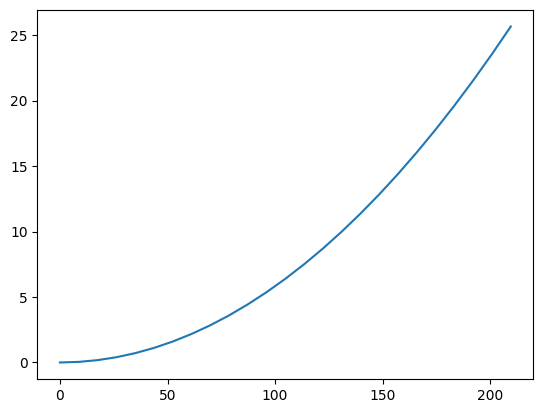

In [46]:
plt.plot(x0, z0)
plt.show()

In [47]:
q0=np.zeros(12*N)

In [48]:
theta0 = np.zeros(N)

for i in range(N):
    if i == 0:
        dzdx = (z0[1] - z0[0]) / (x0[1] - x0[0])
    elif i == N-1:
        dzdx = (z0[-1] - z0[-2]) / (x0[-1] - x0[-2])
    else:
        dzdx = (z0[i+1] - z0[i-1]) / (x0[i+1] - x0[i-1])

    theta0[i] = -np.arctan2(dzdx, 1.0)

In [49]:
q0[0*N:1*N] = x0
q0[2*N:3*N] = 0.0
q0[4*N:5*N] = z0

q0[6*N:7*N] = 0.0       # phi
q0[8*N:9*N] = theta0    # theta
q0[10*N:11*N] = 0.0     # psi

In [50]:
def fun1(x_int,φ,θ,ψ,t):
    
    def fun1_(x_int,φ,θ,ψ,t):
        A=mp*1/2*(1-x_int)*1/2*(1+x_int)*np.identity(3)
        B=np.zeros((3,3))

        Pi = Πe(φ, θ, ψ)
        Ie = I_e_rho(φ, θ, ψ)
     
        D=1/2*(1-x_int)*1/2*(1+x_int)* Pi.T @ Ie @ Pi
            
        return h/2*np.block([[A, B], [B, D]])

    res = np.array([fun1_(xi,φ,θ,ψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun2_1(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_1_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_1_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun2_2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_2_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=-1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1-x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_2_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun3_1(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun3_1_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3)  
        B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_1_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)  

    
def fun3_2(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun3_2_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3) 
        B=1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_2_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun4_1(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun4_1_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3)  
        B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_1_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun4_2(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun4_2_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3) 
        B=1/2*(1-x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_2_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun5_1(x_int, li):
    
    def fun5_1_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1+x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_1_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun5_2(x_int, li):
    
    def fun5_2_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1-x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_2_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun6_1(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_1_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)  
    
    res = np.array([fun6_1_(xi,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun6_2(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_2_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1-x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1-x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun6_2_(xi,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun7_1(x_int,x,y,z):
   
    def fun7_1_(x_int,x,y,z):
        A=1/2*(1+x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_1_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun7_2(x_int,x,y,z):
   
    def fun7_2_(x_int,x,y,z):
        A=1/2*(1-x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_2_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

In [51]:
def body_frame_nu(u_dot_xyz, phi, theta, psi, dphi, dtheta, dpsi):
    """Eq. (64): rotate spatial velocity + convert Euler rates -> body-frame nu."""
    Re_b = Ret_e_t(phi, theta, psi)
    w_e  = Πe(phi, theta, psi) @ np.array([dphi, dtheta, dpsi])   # Eq. (100)
    nu_lin = Re_b.T @ np.asarray(u_dot_xyz)
    nu_ang = Re_b.T @ w_e
    return np.concatenate([nu_lin, nu_ang])

In [52]:
def environmental_force(t):
    """
    Environmental force/moment acting on vessel.
    Body frame generalized load:
    [Fx, Fy, Fz, Mx, My, Mz]
    """

    Fx_env = 8.0 * np.sin(2*np.pi*t/10.0+0.5)
    Fy_env = 7.0 * np.sin(2*np.pi*t/12.0+0.5)
    Fz_env = 0.0

    Mx_env = 0.0
    My_env = 0.0
    Mz_env = 10.0 * np.sin(2*np.pi*t/15.0+0.5)

    return np.array([
        Fx_env,
        Fy_env,
        Fz_env,
        Mx_env,
        My_env,
        Mz_env
    ])

In [53]:
def static_solution(Q, T): 
    x, y, z = Q[0:N], Q[1*N:2*N], Q[2*N:3*N]
    φ, θ, ψ = Q[3*N:4*N], Q[4*N:5*N], Q[5*N:6*N]
    
    f2 = []
    f5 = []
    f7 = []
    f8 = []
   
    for j in range(N):
        if j == N-1:
            
            eta = np.array([x[-1]-x0[-1], y[-1], z[-1]-z0[-1], φ[-1], θ[-1], ψ[-1]])


            g_eta = T.G@eta
    
            res_f2 = integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1], x[j], y[j], z[j], φ[j], θ[j], ψ[j], h), -1.0, 1.0, n=1)[0]
            res_f5 = integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
            
            f2.append(res_f2)
            f5.append(res_f5)
            f7.append(np.zeros(6))
            
            J = np.block([
                [Ret_e_t(φ[j], θ[j], ψ[j]).T, np.zeros((3, 3))],
                [np.zeros((3, 3)), Ret_e_t(φ[j], θ[j], ψ[j]).T @ Πe(φ[j], θ[j], ψ[j])]
            ])
            F_body = (
                # g_eta 
                      + np.array([Fx_0, 0, 0, 0, 0, 0]))
            F_generalized = J.T @ F_body
            f8.append(F_generalized.flatten())
        elif j==0:
            f2.append(np.zeros(6))
            f5.append(np.zeros(6))
            res_f7 = integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
            f7.append(res_f7)
            f8.append(np.zeros(6)) 
        else:
            res_f2 = (integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1], x[j], y[j], z[j], φ[j], θ[j], ψ[j], h), -1.0, 1.0, n=1)[0]
                      + integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j], y[j], z[j], φ[j], θ[j], ψ[j], x[j+1], y[j+1], z[j+1], φ[j+1], θ[j+1], ψ[j+1], h), -1.0, 1.0, n=1)[0])
            
            res_f5 = (integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                      + integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f2.append(res_f2)
            f5.append(res_f5)

            f7.append(np.zeros(6))
            f8.append(np.zeros(6)) 

    f2 = np.array(f2) 
    f5 = np.array(f5) 
    f7 = np.array(f7)
    f8 = np.array(f8)
    
    f_sum = (f2 + f5 
             # + f7 
             + f8)
        
    return f_sum.flatten()

In [54]:
T_1 = MyTime()

In [55]:
q0_stat = np.concatenate((q0[0:N], q0[2*N:3*N], q0[4*N:5*N], q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N]))

In [56]:
root_ = root(static_solution, q0_stat, 
             method='lm', 
             args=(T_1,))

In [57]:
root_

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 0.000e+00  0.000e+00 ...  3.083e-05 -4.666e-08]
       x: [ 5.196e-01  9.248e+00 ... -1.147e-08 -1.147e-08]
   cov_x: [[ 5.879e+14  5.860e+14 ... -8.334e+13 -8.332e+13]
           [ 5.860e+14  5.842e+14 ... -8.306e+13 -8.304e+13]
           ...
           [-8.334e+13 -8.306e+13 ...  1.296e+13  1.295e+13]
           [-8.332e+13 -8.304e+13 ...  1.295e+13  1.295e+13]]
  method: lm
    nfev: 8926
    fjac: [[-1.325e+10  0.000e+00 ...  6.855e-01  1.779e-09]
           [-2.090e-04 -1.325e+10 ... -1.081e-14  6.656e-01]
           ...
           [ 0.000e+00  0.000e+00 ...  7.051e-09 -2.926e-01]
           [ 0.000e+00  0.000e+00 ...  4.436e-09  1.069e-09]]
    ipvt: [124 149 ...  51  76]
     qtf: [-4.011e-03  4.799e-06 ... -7.631e-17 -2.006e-16]

In [58]:
x0_, y0_, z0_, φ0_, θ0_, ψ0_ = (root_.x[:N], 
                                root_.x[1*N:2*N], 
                                root_.x[2*N:3*N], 
                                root_.x[3*N:4*N], 
                                root_.x[4*N:5*N], 
                                root_.x[5*N:6*N])

In [59]:
q0 = np.concatenate((root_.x[:N],
      np.zeros(N),
      root_.x[1*N:2*N], 
      np.zeros(N),
      root_.x[2*N:3*N],
      np.zeros(N),
      root_.x[3*N:4*N],
      np.zeros(N),
      root_.x[4*N:5*N],
      np.zeros(N),
      root_.x[5*N:6*N],
      np.zeros(N)))                                    # start from static solution

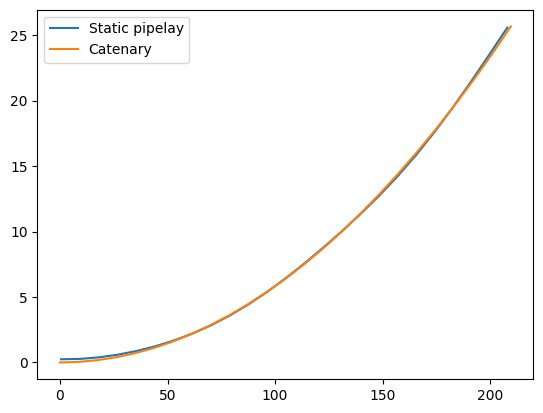

In [60]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

### Dynamic Simulation

In [61]:
def dynamic_func(t, Q, T):
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
        
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
    
    for j in range(N):
        
        if j == N-1:
            nu = body_frame_nu(np.array([dx[j], dy[j], dz[j]]), φ[j], θ[j], ψ[j], dφ[j], dθ[j], dψ[j])
            C_nu = T.CRB(T.MRB, nu) + T.CA(T.MA, nu)
            eta = np.array([x[-1]-x0_[-1], y[-1]-y0_[-1], z[-1]-z0_[-1], φ[-1]-φ0_[-1], θ[-1]-θ0_[-1], ψ[-1]-ψ0_[-1]])
          
            g_eta = T.G @ eta 
            
            D_nu = T.D

            
            J = np.block([
                [Ret_e_t(φ[j],θ[j],ψ[j]).T, np.zeros((3,3))],
                [np.zeros((3,3)), Ret_e_t(φ[j],θ[j],ψ[j]).T @ Πe(φ[j],θ[j],ψ[j])]
            ])

            M_generalized = J.T @ T.M @ J
            
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0] + M_generalized )
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append((integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0]))
            f7.append(np.zeros(6))

            if t>2:
                F_env = environmental_force(t)
            else:
                F_env = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

            F_pipe = np.array([Fx_0, 0.0, 0.0, 0.0, 0.0, 0.0])
            
            F_body = (
                    g_eta
                    + (C_nu + D_nu) @ nu
                    + F_pipe
                    + F_env
                )
            
            F_generalized = J.T @ F_body
            f8.append(F_generalized)
        elif j==0:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0])
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            res_f7 = integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
            f6.append(np.zeros(6))
            f7.append(res_f7)
            f8.append(np.zeros(6)) 
        else:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0]
                     +integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],φ[j+1],θ[j+1],ψ[j+1],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun3_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun4_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun6_2(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(np.zeros(6))
            f8.append(np.zeros(6))
         
        if t>0.01 and j>0:
            ax=Ret_e_t(φ[j],θ[j],ψ[j]).T @ ne(x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1],x[j], y[j], z[j], φ[j], θ[j], ψ[j],h).T

            T.top_tension=max(T.top_tension, abs(ax[0]))            

            ben0=Ret_e_t(φ[j],θ[j],ψ[j]).T @ me( φ[j-1], θ[j-1], ψ[j-1], φ[j],θ[j],ψ[j],h).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)    
    

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7)
    f8=np.vstack(f8)
    
    f_sum = -(f2 + f3 + f4 + f5 + f6 
              # + f7 
              + f8)

    X_raw = np.linalg.solve(f1, f_sum)
    
    X = X_raw.reshape(N, 6)

    ddx, ddy, ddz, ddφ, ddθ, ddψ = X.T  

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)


        
    if t>T.progression[0]:
        
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock , flush=True)
        T.wall_clock = datetime.now() 
    
    T.my_iter+=1 

    if np.any(np.abs(ans) > 1e6) or np.any(np.isnan(ans)):
        print(f"\n!!! CRITICAL SYSTEM EXPLOSION AT t = {t} !!!")
         
        raise ValueError("Simulation aborted due to Inf/NaN generation.")

    return ans 

In [62]:
T_3 = MyTime()

In [63]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func, 
                tspan, 
                q0, 
                method='BDF',
                args=(T_3,))
print(datetime.now() - startTime1)

Physical time:  3.1939197559401085  Iteration wall-clock time:  0:00:00.046563
Physical time:  1.3275452756511108  Iteration wall-clock time:  0:00:05.172554
Physical time:  7.36184198315616  Iteration wall-clock time:  0:00:00.054547
Physical time:  7.36184198315616  Iteration wall-clock time:  0:00:00.026965
Physical time:  13.39613869066121  Iteration wall-clock time:  0:00:00.026825
Physical time:  13.39613869066121  Iteration wall-clock time:  0:00:00.064757
Physical time:  20.173305317837126  Iteration wall-clock time:  0:00:00.037865
Physical time:  20.173305317837126  Iteration wall-clock time:  0:00:00.027551
Physical time:  26.950471945013042  Iteration wall-clock time:  0:00:00.026753
Physical time:  26.950471945013042  Iteration wall-clock time:  0:00:00.026999
Physical time:  33.42397132882125  Iteration wall-clock time:  0:00:00.027427
Physical time:  33.42397132882125  Iteration wall-clock time:  0:00:00.057033
Physical time:  39.89747071262946  Iteration wall-clock time

### Results

In [64]:
# number of iterations
T_3.my_iter

331

In [65]:
# max axial tension
T_3.top_tension

1513385.0524822334

In [66]:
# max bending strain
T_3.sagbend_strain

4.318296978350461e-08

In [67]:
fin=us_

In [68]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.034e-02 ...  6.306e+01  7.000e+01]
        y: [[ 5.196e-01  5.196e-01 ...  5.196e-01  5.196e-01]
            [ 9.248e+00  9.248e+00 ...  9.248e+00  9.248e+00]
            ...
            [ 0.000e+00 -9.455e-16 ... -5.440e-08 -6.878e-08]
            [ 0.000e+00  1.783e-21 ... -1.473e-08 -1.859e-08]]
      sol: None
 t_events: None
 y_events: None
     nfev: 30
     njev: 1
      nlu: 7

In [69]:
t=fin.t
fin=fin.y.T

In [70]:
t.shape, fin.shape

((15,), (15, 300))

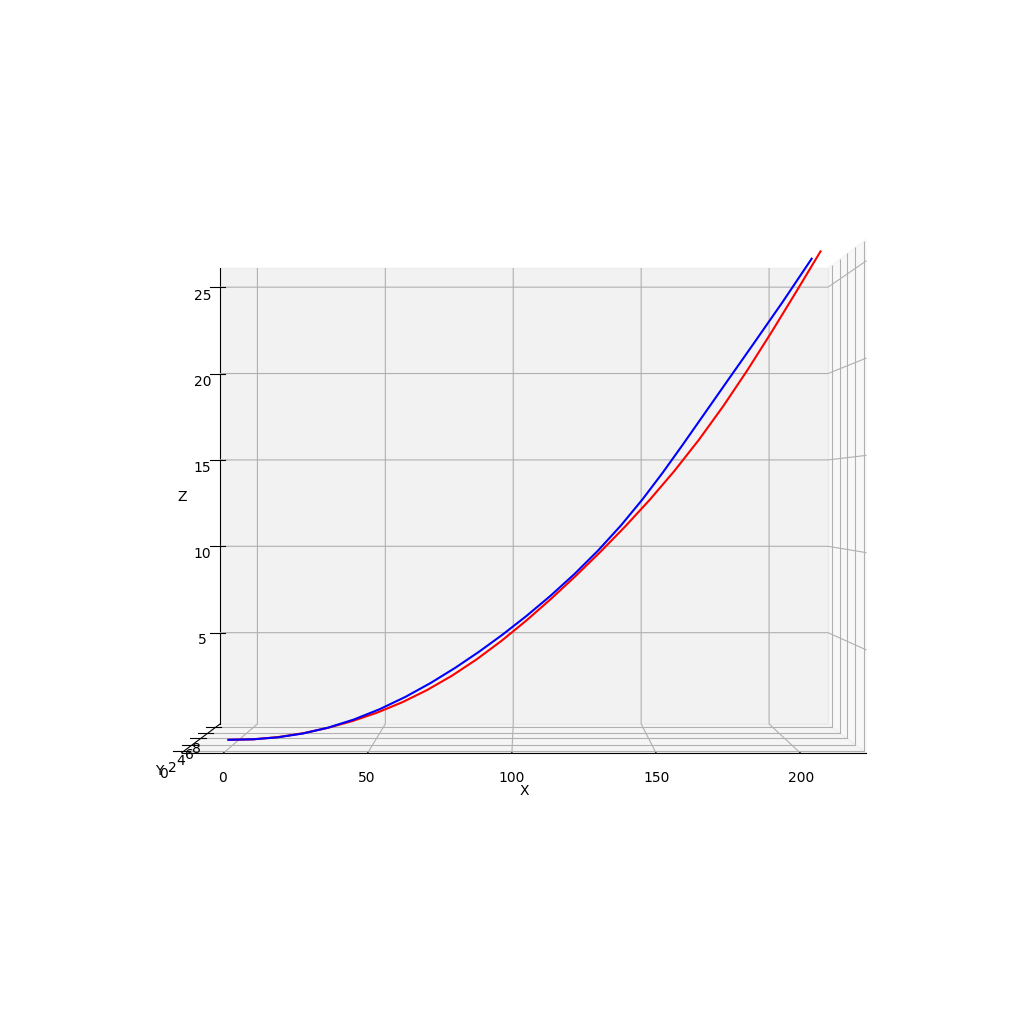

In [71]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [72]:
X,Y,Z

(array([  0.51964289,   9.24814736,  17.97590748,  26.70214222,
         35.42617688,  44.14729107,  52.86454188,  61.57663777,
         70.28194496,  78.97869362,  87.66538031,  96.34122776,
        105.00644062, 113.66201601, 122.30907697, 130.94796873,
        139.57749085, 148.19456924, 156.79454033, 165.37215649,
        173.9233069 , 182.4470406 , 190.9468842 , 199.43028424,
        207.90581223]),
 array([2.77848334e-06, 2.67328292e-06, 1.80032224e-06, 1.44911122e-06,
        2.95688302e-06, 7.19836280e-06, 1.41556582e-05, 2.27508454e-05,
        3.10577985e-05, 3.68856277e-05, 3.85801853e-05, 3.57745794e-05,
        2.97857254e-05, 2.34317230e-05, 2.02261616e-05, 2.31399214e-05,
        3.33282895e-05, 4.93154073e-05, 6.70488890e-05, 8.09801556e-05,
        8.59548507e-05, 7.93327969e-05, 6.25430173e-05, 4.13383386e-05,
        2.43817425e-05]),
 array([ 0.24416505,  0.27213063,  0.38949331,  0.59047569,  0.8711529 ,
         1.23131813,  1.67525387,  2.21089584,  2.84740019,  

In [73]:
X0,Y0,Z0

(array([  0.51964289,   9.24814756,  17.97590728,  26.70214402,
         35.42619006,  44.1473326 ,  52.86463244,  61.57679336,
         70.28216592,  78.97895548,  87.66563391,  96.34141419,
        105.00651918, 113.66199307, 122.30901968, 130.94799377,
        139.57773007, 148.19512152, 156.79542013, 165.37325346,
        173.92438076, 182.44777903, 190.94702647, 199.42976388,
        207.90483918]),
 array([2.77848334e-06, 2.67535083e-06, 2.57221918e-06, 2.46909845e-06,
        2.36600008e-06, 2.26293769e-06, 2.15992742e-06, 2.05698750e-06,
        1.95413692e-06, 1.85139291e-06, 1.74876754e-06, 1.64626436e-06,
        1.54387724e-06, 1.44159375e-06, 1.33940327e-06, 1.23730704e-06,
        1.13532553e-06, 1.03349989e-06, 9.31886271e-07, 8.30543717e-07,
        7.29516141e-07, 6.28811532e-07, 5.28387478e-07, 4.28156016e-07,
        3.28014531e-07]),
 array([ 0.24416505,  0.27213092,  0.38953839,  0.59044271,  0.87077237,
         1.23025534,  1.67323143,  2.2078179 ,  2.84343049,  

In [74]:
us=fin.T

In [75]:
us.shape

(300, 15)

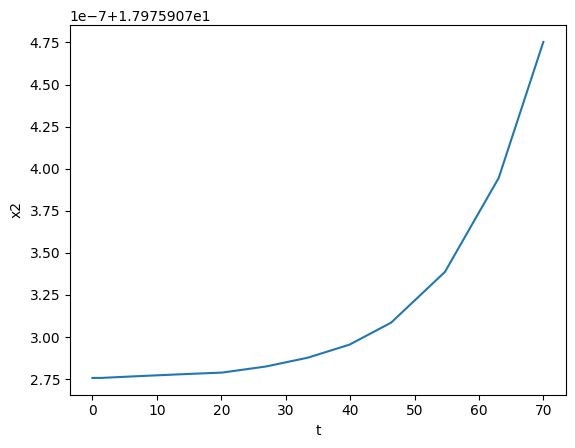

In [76]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

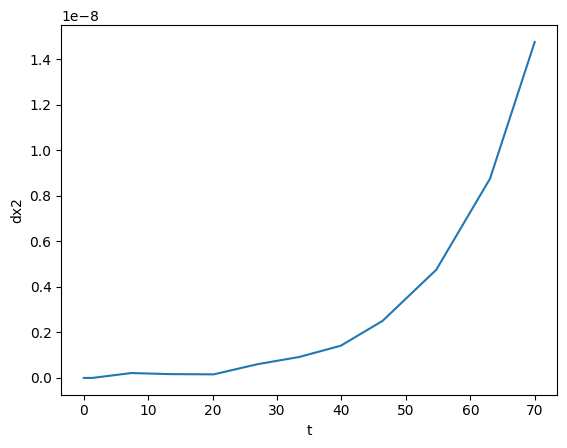

In [77]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

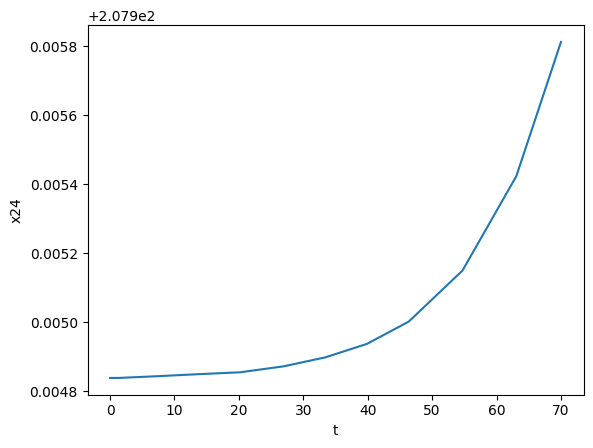

In [78]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

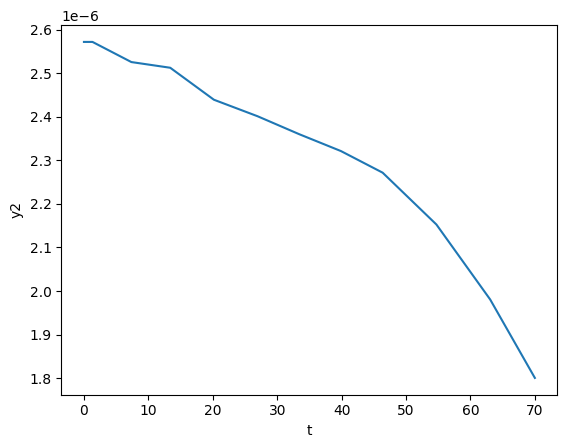

In [79]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

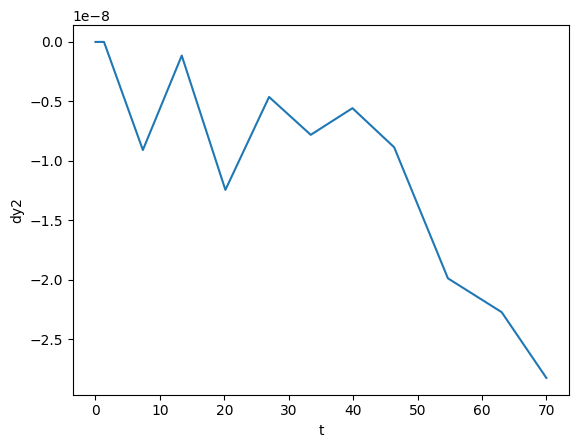

In [80]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

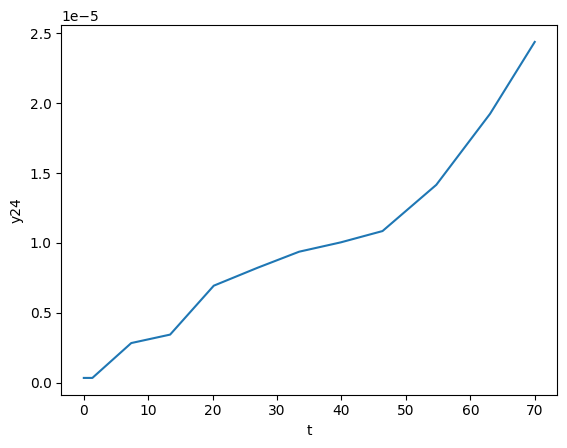

In [81]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

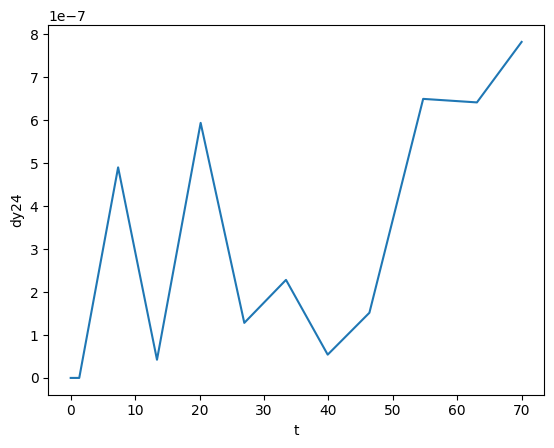

In [82]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

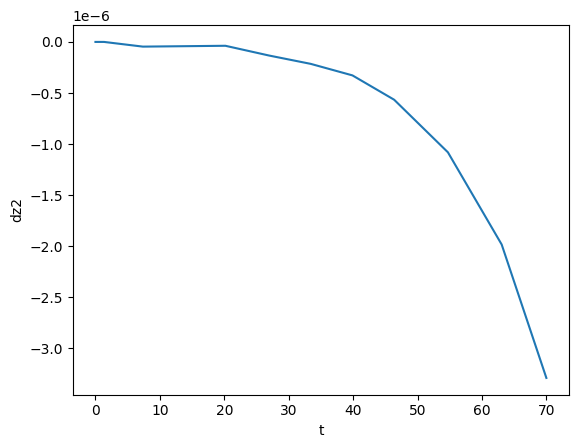

In [83]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

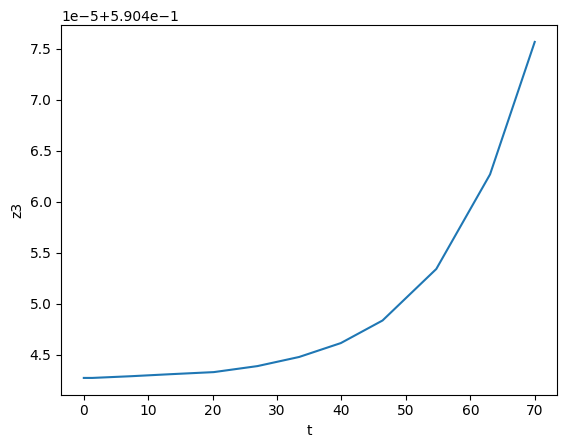

In [84]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

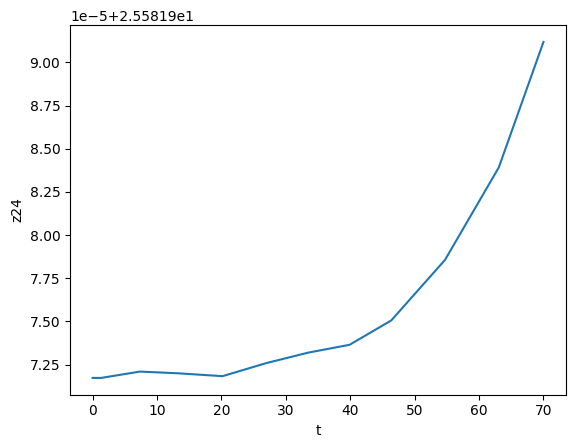

In [85]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

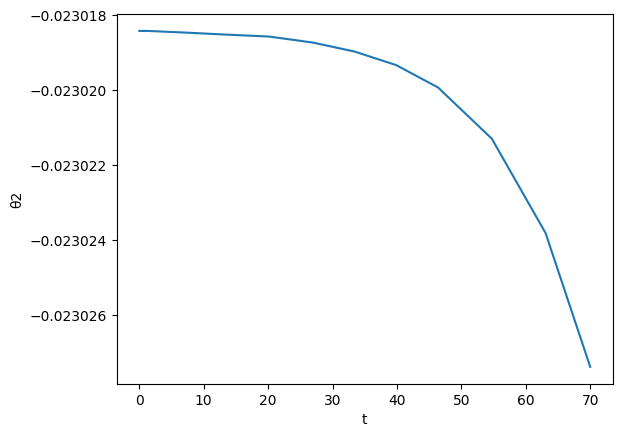

In [86]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

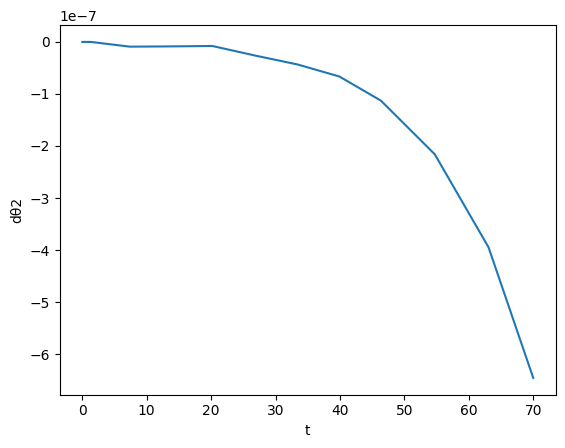

In [87]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

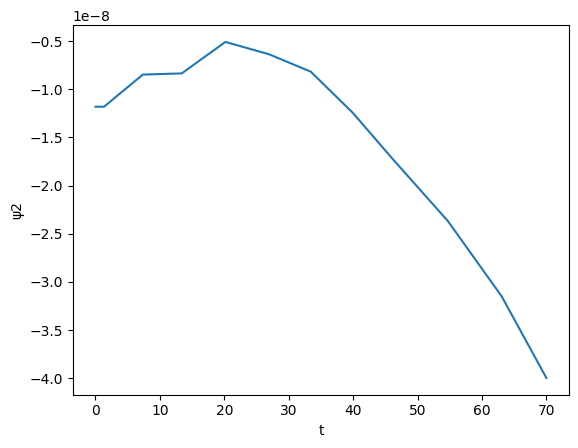

In [88]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

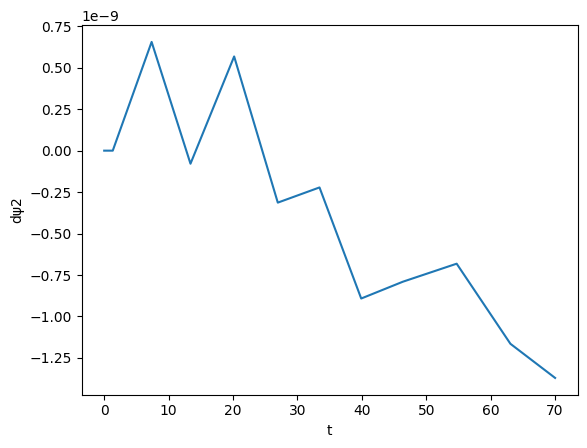

In [89]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

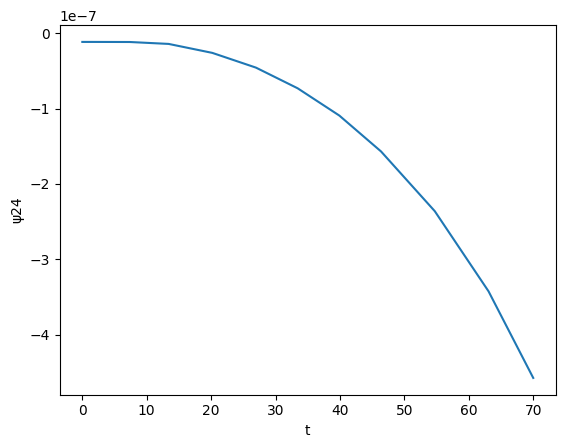

In [90]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [91]:
X010=us.T[:,0*N:1*N]

In [92]:
Y010=us.T[:,2*N:3*N]

In [93]:
Z010=us.T[:,4*N:5*N]

In [94]:
# simulation = np.stack([X010, Y010, Z010], axis=2)  

# FPS = 5
# STEP = 1                      
# frame_duration = 1000 / FPS

# sim = simulation[::STEP]
# n_points = sim.shape[1]

# frames = [
#     go.Frame(
#         data=[go.Scatter3d(x=sim[t, :, 0], y=sim[t, :, 1], z=sim[t, :, 2])],
#         traces=[0],
#         name=f"t={t}",
#     )
#     for t in range(sim.shape[0])
# ]

# fig = go.Figure(
#     data=[go.Scatter3d(
#         x=sim[0, :, 0], y=sim[0, :, 1], z=sim[0, :, 2],
#         mode="lines+markers",
#         marker=dict(size=5, color=list(range(n_points)), colorscale="Viridis"),
#         line=dict(width=4),
#     )],
#     frames=frames,
# )

# fig.update_layout(
#     title="Pipelay Simulation",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 250], autorange=False),
#         yaxis=dict(range=[-50, 50], autorange=False),
#         zaxis=dict(range=[0, 100], autorange=False),
#         aspectmode="manual",
#         aspectratio=dict(x=4, y=1, z=1),
#         camera=dict(
#             eye=dict(x=1.5, y=-1.5, z=0.8),
#             center=dict(x=0, y=0, z=0),
#             up=dict(x=0, y=0, z=1),
#         ),
#     ),
#     uirevision="keep",
#     updatemenus=[{
#         "type": "buttons",
#         "showactive": False,
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {
#                     "frame": {"duration": frame_duration, "redraw": True}, 
#                     "transition": {"duration": 0},
#                     "fromcurrent": True,
#                     "mode": "immediate",
#                 }],
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {
#                     "frame": {"duration": 0, "redraw": False},
#                     "transition": {"duration": 0},
#                     "mode": "immediate",
#                 }],
#             },
#         ],
#     }],
# )

# fig.show()

# # fig.write_html("pipe.html")